[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juansensio/axr/blob/master/axr/00_intro.ipynb)

## Aprendizaje por refuerzo


## Ejemplo de aplicación: tres en raya


In [7]:
import numpy as np


class Board():
    def __init__(self):
        self.state = np.zeros((3,3))

    def valid_moves(self):
        return [(i, j) for j in range(3) for i in range(3) if self.state[i, j] == 0]

    def update(self, symbol, row, col):
        if self.state[row, col] == 0:
            self.state[row, col] = symbol
        else:
            raise ValueError ("movimiento ilegal !")

    def is_game_over(self):
        # comprobar filas y columnas
        if (self.state.sum(axis=0) == 3).sum() >= 1 or (self.state.sum(axis=1) == 3).sum() >= 1:
            return 1
        if (self.state.sum(axis=0) == -3).sum() >= 1 or (self.state.sum(axis=1) == -3).sum() >= 1:
            return -1
        # comprobar diagonales
        diag_sums = [
            sum([self.state[i, i] for i in range(3)]),
            sum([self.state[i, 3 - i - 1] for i in range(3)]),
        ]
        if diag_sums[0] == 3 or diag_sums[1] == 3:
            return 1
        if diag_sums[0] == -3 or diag_sums[1] == -3:
            return -1
        # empate
        if len(self.valid_moves()) == 0:
            return 0
        # seguir jugando
        return None

    def reset(self):
        self.state = np.zeros((3,3))


In [8]:
from tqdm import tqdm

class Game():
    def __init__(self, player1, player2):
        player1.symbol = 1
        player2.symbol = -1
        self.players = [player1, player2]
        self.board = Board()

    def selfplay(self, rounds=100):
        wins = [0, 0]
        for i in tqdm(range(1, rounds + 1)):
            self.board.reset()
            for player in self.players:
                player.reset()
            game_over = False
            while not game_over:
                for player in self.players:
                    action = player.move(self.board)
                    self.board.update(player.symbol, action[0], action[1])
                    for player in self.players:
                        player.update(self.board)
                    if self.board.is_game_over() is not None:
                        game_over = True
                        break
            self.reward()
            for ix, player in enumerate(self.players):
                if self.board.is_game_over() == player.symbol:
                    wins[ix] += 1
        return wins


    def reward(self):
        winner = self.board.is_game_over()
        if winner == 0: # empate
            for player in self.players:
                player.reward(0.5)
        else: # le damos 1 recompensa al jugador que gana
            for player in self.players:
                if winner == player.symbol:
                    player.reward(1)
                else:
                    player.reward(0)

In [9]:
class Agent():
    def __init__(self, alpha=0.5, prob_exp=0.5):
        self.value_function = {} # tabla con pares estado -> valor
        self.alpha = alpha         # learning rate
        self.positions = []       # guardamos todas las posiciones de la partida
        self.prob_exp = prob_exp   # probabilidad de explorar

    def reset(self):
        self.positions = []

    def move(self, board, explore=True):
        valid_moves = board.valid_moves()
        # exploracion
        if explore and np.random.uniform(0, 1) < self.prob_exp:
            # vamos a una posición aleatoria
            ix = np.random.choice(len(valid_moves))
            return valid_moves[ix]
        # explotacion
        # vamos a la posición con más valor
        max_value = -1000
        for row, col in valid_moves:
            next_board = board.state.copy()
            next_board[row, col] = self.symbol
            next_state = str(next_board.reshape(3*3))
            value = 0 if self.value_function.get(next_state) is None else self.value_function.get(next_state)
            if value >= max_value:
                max_value = value
                best_row, best_col = row, col
        return best_row, best_col

    def update(self, board):
        self.positions.append(str(board.state.reshape(3*3)))


    def reward(self, reward):
        # al final de la partida (cuando recibimos la recompensa)
        # iteramos por tods los estados actualizando su valor en la tabla
        for p in reversed(self.positions):
            if self.value_function.get(p) is None:
                self.value_function[p] = 0
            self.value_function[p] += self.alpha * (reward - self.value_function[p])
            reward = self.value_function[p]

In [10]:
agent1 = Agent(prob_exp=0.5)
agent2 = Agent()

game = Game(agent1, agent2)

game.selfplay(300000)

  0%|          | 0/300000 [00:00<?, ?it/s]

100%|██████████| 300000/300000 [35:19<00:00, 141.53it/s] 


[170732, 78282]

In [11]:
import pandas as pd

funcion_de_valor = sorted(agent1.value_function.items(), key=lambda kv: kv[1], reverse=True)
tabla = pd.DataFrame({'estado': [x[0] for x in funcion_de_valor], 'valor': [x[1] for x in funcion_de_valor]})

tabla

,estado,valor
0,[ 1. -1. 1. -1. 1. -1. 1. 1. -1.],1.0
1,[ 1. -1. 1. -1. 0. -1. 1. 1. -1.],1.0
2,[ 1. 1. 1. -1. -1. 0. 1. 0. -1.],1.0
3,[ 1. -1. -1. -1. 1. 1. -1. 1. 1.],1.0
4,[ 1. -1. -1. -1. 0. 1. -1. 1. 1.],1.0
...,...,...
5472,[-1. 1. 1. -1. -1. 1. 0. 1. -1.],0.0
5473,[-1. -1. 1. 1. -1. 1. 1. -1. 0.],0.0
5474,[-1. 1. 1. -1. -1. 0. 0. 1. 0.],0.0
5475,[ 0. 1. -1. 0. 0. -1. 1. 1. -1.],0.0


In [12]:
import pickle

with open('agente.pickle', 'wb') as handle:
    pickle.dump(agent1.value_function, handle, protocol=pickle.HIGHEST_PROTOCOL)

## Pruebas con otras tablas y valores de agentes

In [13]:
class Board43():
    """Tablero de 4 columnas × 3 filas. Gana quien alinee 3 en raya."""
    ROWS, COLS = 3, 4

    def __init__(self):
        self.state = np.zeros((self.ROWS, self.COLS))

    def valid_moves(self):
        return [(i, j) for i in range(self.ROWS)
                        for j in range(self.COLS)
                        if self.state[i, j] == 0]

    def update(self, symbol, row, col):
        if self.state[row, col] == 0:
            self.state[row, col] = symbol
        else:
            raise ValueError("movimiento ilegal!")

    def is_game_over(self):
        s = self.state
        # Filas: buscar 3 consecutivos
        for i in range(self.ROWS):
            for j in range(self.COLS - 2):
                total = s[i, j] + s[i, j+1] + s[i, j+2]
                if total == 3:  return  1
                if total == -3: return -1
        # Columnas: las 3 filas completan siempre una columna
        for j in range(self.COLS):
            total = s[:, j].sum()
            if total == 3:  return  1
            if total == -3: return -1
        # Diagonales de longitud 3
        for i in range(self.ROWS - 2):
            for j in range(self.COLS - 2):
                d1 = s[i,j] + s[i+1,j+1] + s[i+2,j+2]
                d2 = s[i,j+2] + s[i+1,j+1] + s[i+2,j]
                if d1 == 3  or d2 == 3:  return  1
                if d1 == -3 or d2 == -3: return -1
        # Empate
        if len(self.valid_moves()) == 0:
            return 0
        return None

    def reset(self):
        self.state = np.zeros((self.ROWS, self.COLS))

In [14]:
from tqdm import tqdm

class Game43(Game):
    def __init__(self, player1, player2):
        player1.symbol = 1
        player2.symbol = -1
        self.players = [player1, player2]
        self.board = Board43()   # <-- único cambio

In [16]:
class Agent():
    def __init__(self, alpha=0.5, prob_exp=0.5):
        self.value_function = {}
        self.alpha = alpha
        self.positions = []
        self.prob_exp = prob_exp

    def reset(self):
        self.positions = []

    def move(self, board, explore=True):
        valid_moves = board.valid_moves()
        if explore and np.random.uniform(0, 1) < self.prob_exp:
            ix = np.random.choice(len(valid_moves))
            return valid_moves[ix]
        max_value = -1000
        for row, col in valid_moves:
            next_board = board.state.copy()
            next_board[row, col] = self.symbol
            next_state = str(next_board.reshape(-1))  # <-- único cambio
            value = 0 if self.value_function.get(next_state) is None else self.value_function.get(next_state)
            if value >= max_value:
                max_value = value
                best_row, best_col = row, col
        return best_row, best_col

    def update(self, board):
        self.positions.append(str(board.state.reshape(-1)))  # <-- único cambio

    def reward(self, reward):
        for p in reversed(self.positions):
            if self.value_function.get(p) is None:
                self.value_function[p] = 0
            self.value_function[p] += self.alpha * (reward - self.value_function[p])
            reward = self.value_function[p]

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

resultados = []

configs = [
    (0.1, 0.1),   # ambos explotan (codiciosos)
    (0.5, 0.5),   # exploración simétrica media
    (0.9, 0.9),   # exploración alta (casi aleatorios)
    (0.9, 0.1),   # A1 explora mucho, A2 explota
    (0.1, 0.9),   # A1 explota, A2 explora mucho
]

ROUNDS = 50_000

for exp1, exp2 in configs:
    a1 = Agent(alpha=0.5, prob_exp=exp1)
    a2 = Agent(alpha=0.5, prob_exp=exp2)
    juego = Game43(a1, a2)
    wins = juego.selfplay(ROUNDS)

    resultados.append({
        'ε₁': exp1, 'ε₂': exp2,
        'victorias_A1': wins[0],
        'victorias_A2': wins[1],
        'empates': ROUNDS - wins[0] - wins[1],
        'estados_A1': len(a1.value_function),
        'estados_A2': len(a2.value_function),
    })

df = pd.DataFrame(resultados)
df['label'] = df.apply(lambda r: f"ε₁={r['ε₁']} / ε₂={r['ε₂']}", axis=1)
print(df[['label','victorias_A1','victorias_A2','empates','estados_A1']].to_string(index=False))

100%|██████████| 50000/50000 [03:47<00:00, 220.04it/s]


          label  victorias_A1  victorias_A2  empates  estados_A1
ε₁=0.1 / ε₂=0.1         37972          8504     3524       15486
ε₁=0.5 / ε₂=0.5         32238         16834      928       51876
ε₁=0.9 / ε₂=0.9         29884         18797     1319       85607
ε₁=0.9 / ε₂=0.1         16558         32807      635       21673
ε₁=0.1 / ε₂=0.9         43964          5651      385       17139


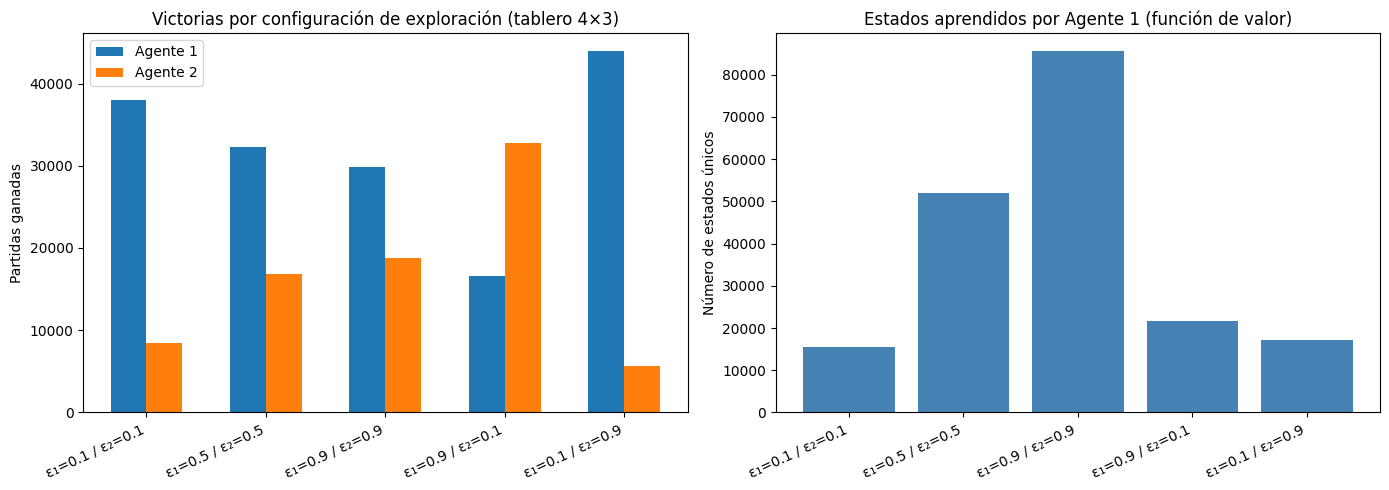

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = range(len(df))
width = 0.3

axes[0].bar([i - width/2 for i in x], df['victorias_A1'], width, label='Agente 1')
axes[0].bar([i + width/2 for i in x], df['victorias_A2'], width, label='Agente 2')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(df['label'], rotation=25, ha='right')
axes[0].set_title('Victorias por configuración de exploración (tablero 4×3)')
axes[0].set_ylabel('Partidas ganadas')
axes[0].legend()

axes[1].bar(list(x), df['estados_A1'], color='steelblue')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(df['label'], rotation=25, ha='right')
axes[1].set_title('Estados aprendidos por Agente 1 (función de valor)')
axes[1].set_ylabel('Número de estados únicos')

plt.tight_layout()
plt.show()